#  Assignment No. 8

###  Title: Implementation of Random Forest using R
###  Dataset: Heart Disease (Cleveland) from UCI via mlbench/URL

# 1. Install & Load Libraries

In [1]:
if (!require(randomForest)) install.packages("randomForest", repos="https://cran.r-project.org")
if (!require(caret))        install.packages("caret",        repos="https://cran.r-project.org")
if (!require(ggplot2))      install.packages("ggplot2",      repos="https://cran.r-project.org")
if (!require(ROCR))         install.packages("ROCR",         repos="https://cran.r-project.org")
if (!require(corrplot))     install.packages("corrplot",     repos="https://cran.r-project.org")

library(randomForest)
library(caret)
library(ggplot2)
library(ROCR)
library(corrplot)

Loading required package: randomForest

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘randomForest’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: caret

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘caret’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: ggplot2

Loading required package: ROCR

Warning message in library(package, lib.loc = lib.loc, character.only = TR

# 2. Load Heart Disease Dataset

In [2]:
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

col_names <- c("age", "sex", "cp", "trestbps", "chol", "fbs",
               "restecg", "thalach", "exang", "oldpeak",
               "slope", "ca", "thal", "target")

heart_data <- tryCatch({
  read.csv(url, header = FALSE, col.names = col_names, na.strings = "?")
}, error = function(e) {
  cat("URL not accessible. Generating synthetic heart data...\n")
  set.seed(42)
  n <- 303
  data.frame(
    age      = sample(29:77, n, replace = TRUE),
    sex      = sample(0:1,   n, replace = TRUE),
    cp       = sample(1:4,   n, replace = TRUE),
    trestbps = sample(94:200, n, replace = TRUE),
    chol     = sample(126:564, n, replace = TRUE),
    fbs      = sample(0:1,   n, replace = TRUE),
    restecg  = sample(0:2,   n, replace = TRUE),
    thalach  = sample(71:202, n, replace = TRUE),
    exang    = sample(0:1,   n, replace = TRUE),
    oldpeak  = round(runif(n, 0, 6.2), 1),
    slope    = sample(1:3,   n, replace = TRUE),
    ca       = sample(0:3,   n, replace = TRUE),
    thal     = sample(c(3,6,7), n, replace = TRUE),
    target   = sample(0:4,   n, replace = TRUE)
  )
})

Warning message in file(file, "rt"):
“cannot open URL 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data': HTTP status was '502 Bad Gateway'”


URL not accessible. Generating synthetic heart data...


# 3. Data Preprocessing

In [3]:
# Binarise target: 0 = no disease, 1 = disease
heart_data$target <- ifelse(heart_data$target > 0, 1, 0)
heart_data$target <- as.factor(heart_data$target)

# Convert categorical variables to factors
heart_data$sex     <- as.factor(heart_data$sex)
heart_data$cp      <- as.factor(heart_data$cp)
heart_data$fbs     <- as.factor(heart_data$fbs)
heart_data$restecg <- as.factor(heart_data$restecg)
heart_data$exang   <- as.factor(heart_data$exang)
heart_data$slope   <- as.factor(heart_data$slope)
heart_data$ca      <- as.factor(heart_data$ca)
heart_data$thal    <- as.factor(heart_data$thal)

# Handle missing values
cat("===== Missing Values Before Imputation =====\n")
print(colSums(is.na(heart_data)))
heart_data <- heart_data[complete.cases(heart_data), ]
cat("Rows after removing NAs:", nrow(heart_data), "\n")

===== Missing Values Before Imputation =====
     age      sex       cp trestbps     chol      fbs  restecg  thalach 
       0        0        0        0        0        0        0        0 
   exang  oldpeak    slope       ca     thal   target 
       0        0        0        0        0        0 
Rows after removing NAs: 303 


# 4. Exploratory Data Analysis (EDA)


===== EDA =====
Dimensions: 303 x 14 
      age        sex     cp        trestbps          chol       fbs     restecg
 Min.   :29.00   0:151   1:70   Min.   : 94.0   Min.   :126.0   0:174   0: 98  
 1st Qu.:43.00   1:152   2:74   1st Qu.:125.0   1st Qu.:231.0   1:129   1:101  
 Median :55.00           3:85   Median :149.0   Median :336.0           2:104  
 Mean   :53.92           4:74   Mean   :149.2   Mean   :340.9                  
 3rd Qu.:65.00                  3rd Qu.:175.5   3rd Qu.:457.0                  
 Max.   :77.00                  Max.   :200.0   Max.   :563.0                  
    thalach      exang      oldpeak      slope   ca     thal    target 
 Min.   : 71.0   0:152   Min.   :0.000   1:114   0:72   3: 90   0: 52  
 1st Qu.:103.0   1:151   1st Qu.:1.500   2: 99   1:75   6:110   1:251  
 Median :131.0           Median :3.300   3: 90   2:67   7:103          
 Mean   :133.6           Mean   :3.255           3:89                  
 3rd Qu.:164.5           3rd Qu.:5.100   

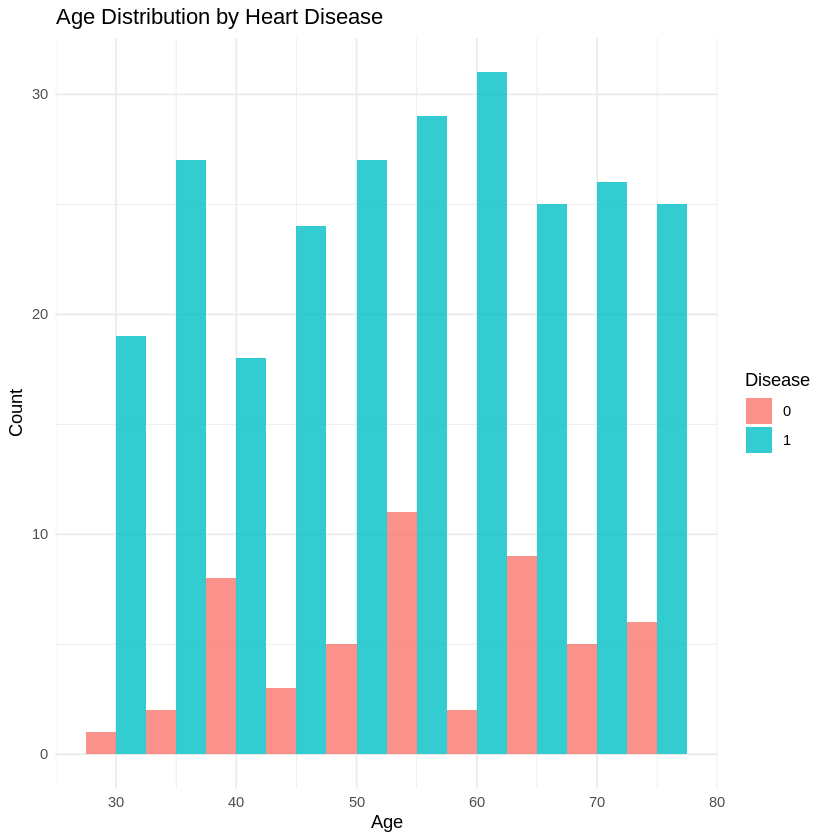

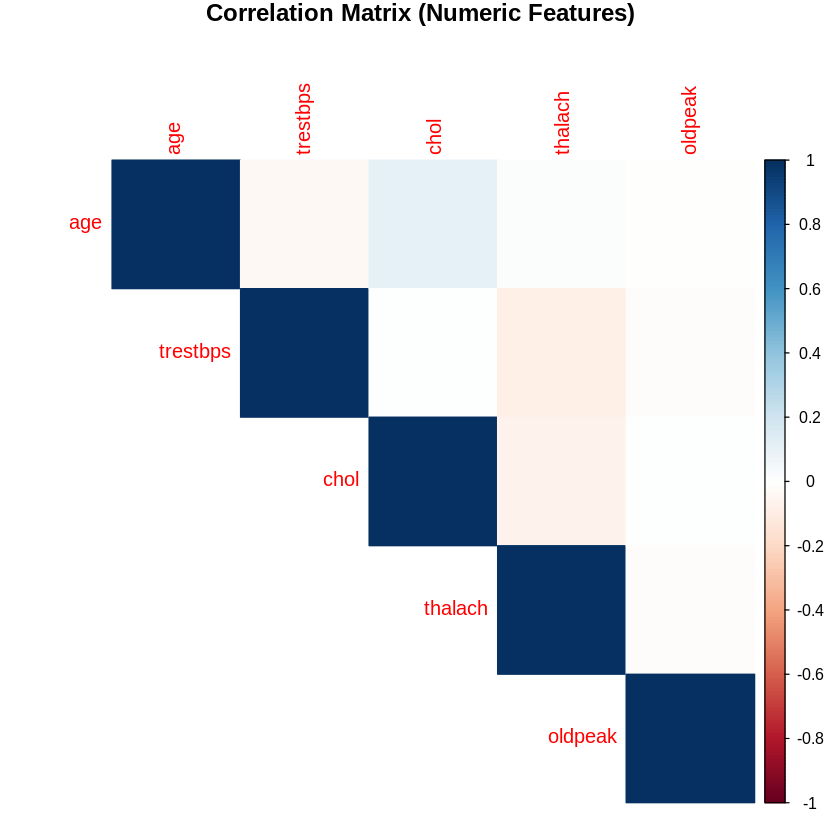

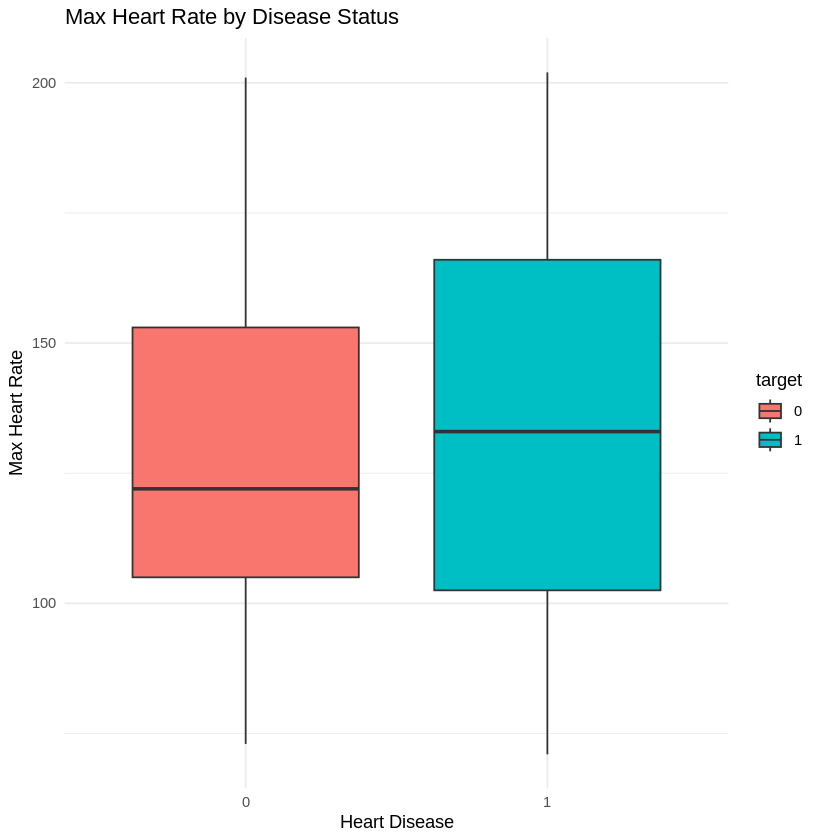

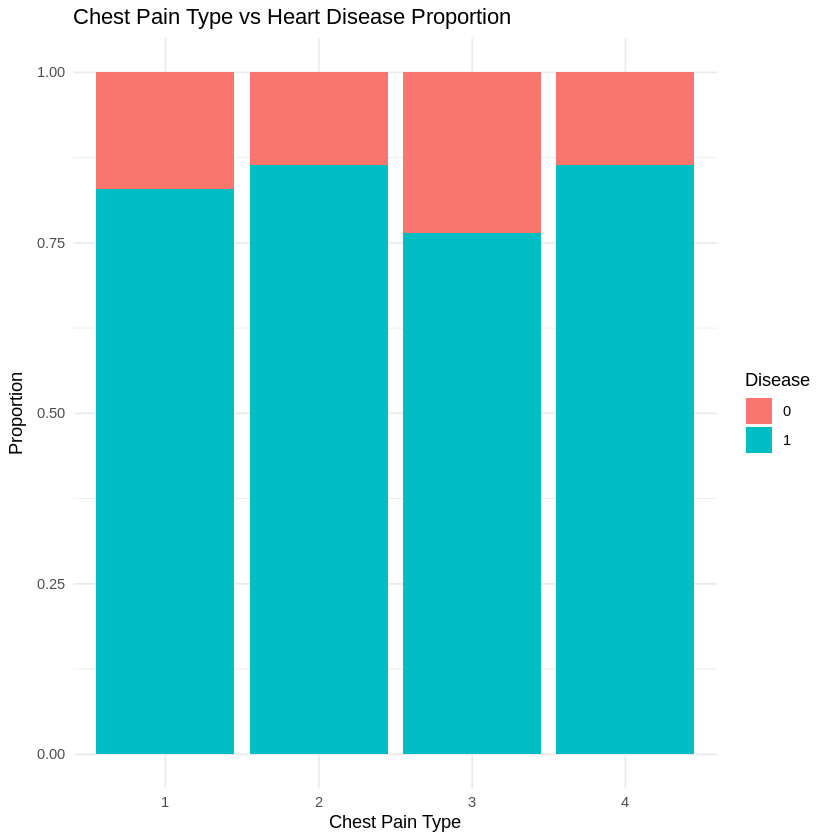

In [4]:
cat("\n===== EDA =====\n")
cat("Dimensions:", nrow(heart_data), "x", ncol(heart_data), "\n")
print(summary(heart_data))

cat("\n===== Class Distribution =====\n")
print(table(heart_data$target))
cat("Proportion:\n")
print(prop.table(table(heart_data$target)))

# EDA Plot 1: Age distribution by target
ggplot(heart_data, aes(x = age, fill = target)) +
  geom_histogram(binwidth = 5, position = "dodge", alpha = 0.8) +
  labs(title = "Age Distribution by Heart Disease",
       x = "Age", y = "Count", fill = "Disease") +
  theme_minimal()

# EDA Plot 2: Correlation matrix (numeric features only)
numeric_cols <- sapply(heart_data, is.numeric)
cor_matrix   <- cor(heart_data[, numeric_cols])
corrplot(cor_matrix,
         method = "color",
         type   = "upper",
         title  = "Correlation Matrix (Numeric Features)",
         mar    = c(0, 0, 1, 0))

# EDA Plot 3: Boxplot for thalach (max heart rate) by target
ggplot(heart_data, aes(x = target, y = thalach, fill = target)) +
  geom_boxplot() +
  labs(title = "Max Heart Rate by Disease Status",
       x = "Heart Disease", y = "Max Heart Rate") +
  theme_minimal()

# EDA Plot 4: Chest pain type distribution
ggplot(heart_data, aes(x = cp, fill = target)) +
  geom_bar(position = "fill") +
  labs(title = "Chest Pain Type vs Heart Disease Proportion",
       x = "Chest Pain Type", y = "Proportion", fill = "Disease") +
  theme_minimal()

# 5. Train / Test Split

In [5]:
set.seed(42)
train_index <- createDataPartition(heart_data$target, p = 0.80, list = FALSE)
train_data  <- heart_data[ train_index, ]
test_data   <- heart_data[-train_index, ]

cat("\n===== Split Sizes =====\n")
cat("Training:", nrow(train_data), "| Test:", nrow(test_data), "\n")


===== Split Sizes =====
Training: 243 | Test: 60 


# 6. Train Random Forest Model

In [6]:
set.seed(42)
rf_model <- randomForest(target ~ .,
                          data       = train_data,
                          ntree      = 500,
                          mtry       = floor(sqrt(ncol(train_data) - 1)),
                          importance = TRUE,
                          proximity  = TRUE)

cat("\n===== Random Forest Model Summary =====\n")
print(rf_model)


===== Random Forest Model Summary =====

Call:
 randomForest(formula = target ~ ., data = train_data, ntree = 500,      mtry = floor(sqrt(ncol(train_data) - 1)), importance = TRUE,      proximity = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 3

        OOB estimate of  error rate: 17.7%
Confusion matrix:
  0   1 class.error
0 0  42 1.000000000
1 1 200 0.004975124


# 7. Classify Test Samples

In [7]:
predictions      <- predict(rf_model, test_data)
predictions_prob <- predict(rf_model, test_data, type = "prob")

# 8. Display Predicted vs Actual Values

In [8]:
cat("\n===== Predicted vs Actual Values (first 20 rows) =====\n")
results_df <- data.frame(
  Index     = 1:nrow(test_data),
  Actual    = test_data$target,
  Predicted = predictions,
  Prob_0    = round(predictions_prob[, 1], 3),
  Prob_1    = round(predictions_prob[, 2], 3),
  Correct   = ifelse(test_data$target == predictions, "Yes", "No")
)
print(head(results_df, 20))


===== Predicted vs Actual Values (first 20 rows) =====
   Index Actual Predicted Prob_0 Prob_1 Correct
4      1      1         1  0.262  0.738     Yes
7      2      1         1  0.116  0.884     Yes
20     3      1         1  0.232  0.768     Yes
21     4      1         1  0.406  0.594     Yes
22     5      1         1  0.138  0.862     Yes
25     6      1         1  0.110  0.890     Yes
26     7      1         1  0.112  0.888     Yes
38     8      1         1  0.284  0.716     Yes
41     9      1         1  0.326  0.674     Yes
48    10      1         1  0.072  0.928     Yes
51    11      1         1  0.098  0.902     Yes
55    12      1         1  0.188  0.812     Yes
59    13      0         1  0.136  0.864      No
68    14      0         1  0.108  0.892      No
74    15      1         1  0.082  0.918     Yes
77    16      1         1  0.196  0.804     Yes
84    17      1         1  0.222  0.778     Yes
87    18      1         1  0.070  0.930     Yes
90    19      1         1  0.130

# 9. Model Evaluation

In [9]:
cm <- confusionMatrix(predictions, test_data$target, positive = "1")
cat("\n===== Confusion Matrix =====\n")
print(cm)

cat("\n===== Key Metrics =====\n")
cat("Accuracy   :", round(cm$overall["Accuracy"],       4), "\n")
cat("Kappa      :", round(cm$overall["Kappa"],          4), "\n")
cat("Sensitivity:", round(cm$byClass["Sensitivity"],    4), "\n")
cat("Specificity:", round(cm$byClass["Specificity"],    4), "\n")
cat("Precision  :", round(cm$byClass["Pos Pred Value"], 4), "\n")
cat("F1 Score   :", round(cm$byClass["F1"],             4), "\n")


===== Confusion Matrix =====
Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0  0  0
         1 10 50
                                          
               Accuracy : 0.8333          
                 95% CI : (0.7148, 0.9171)
    No Information Rate : 0.8333          
    P-Value [Acc > NIR] : 0.583387        
                                          
                  Kappa : 0               
                                          
 Mcnemar's Test P-Value : 0.004427        
                                          
            Sensitivity : 1.0000          
            Specificity : 0.0000          
         Pos Pred Value : 0.8333          
         Neg Pred Value :    NaN          
             Prevalence : 0.8333          
         Detection Rate : 0.8333          
   Detection Prevalence : 1.0000          
      Balanced Accuracy : 0.5000          
                                          
       'Positive' Class : 1               
      

# 10. ROC Curve

AUC: 0.454 


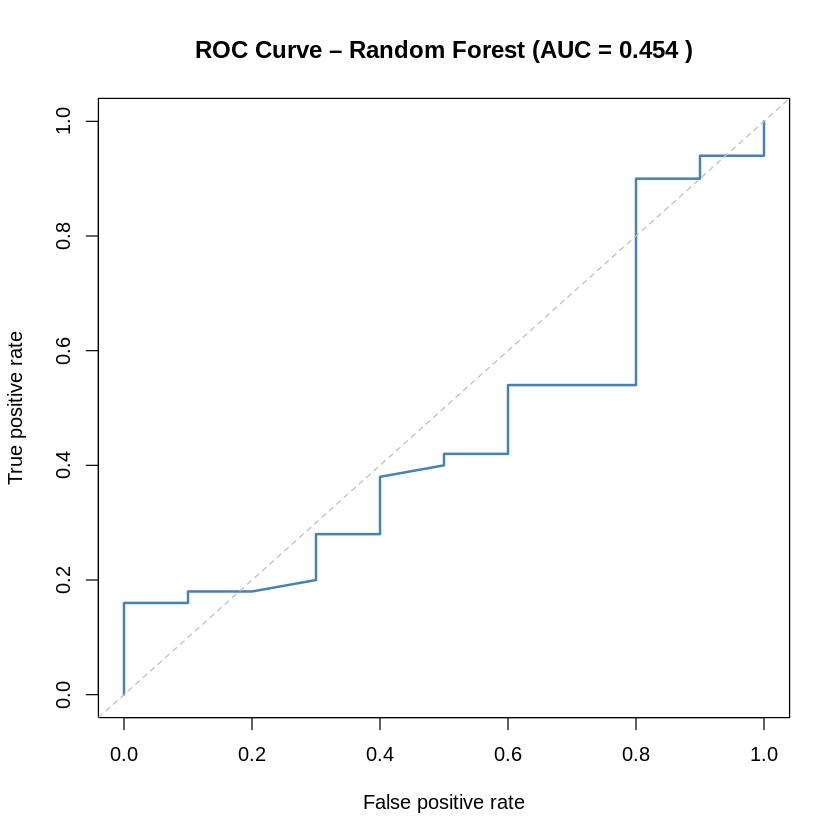

In [10]:
pred_obj <- prediction(predictions_prob[, 2], test_data$target)
perf_roc  <- performance(pred_obj, "tpr", "fpr")
auc_val   <- performance(pred_obj, "auc")@y.values[[1]]

plot(perf_roc,
     main = paste("ROC Curve – Random Forest (AUC =", round(auc_val, 3), ")"),
     col  = "steelblue", lwd = 2)
abline(a = 0, b = 1, lty = 2, col = "gray")
cat("AUC:", round(auc_val, 4), "\n")

# 11. Feature Importance


===== Feature Importance =====
                  0           1 MeanDecreaseAccuracy MeanDecreaseGini  Feature
oldpeak   5.9053023  2.68161127            4.9187452        11.002997  oldpeak
chol     -1.3250007  2.71767228            1.9927801        10.094326     chol
thalach  -0.9682414  2.29070001            1.7508365         9.391064  thalach
age      -0.1489237  0.14124488            0.2338941         8.585759      age
trestbps -2.5895674 -1.06665502           -2.0469129         8.234242 trestbps
cp       -0.7769280 -1.93678881           -2.1506124         4.313245       cp
ca       -1.5805160  1.19776003            0.4284989         3.983270       ca
restecg  -0.8598329  1.08677230            0.5840843         3.315241  restecg
thal     -2.4647225 -1.86606794           -2.8112901         2.627702     thal
slope    -1.1080692 -1.67904890           -1.9971821         2.618716    slope
exang     1.0458977 -0.01643782            0.5056014         1.546632    exang
sex      -0.4923782 

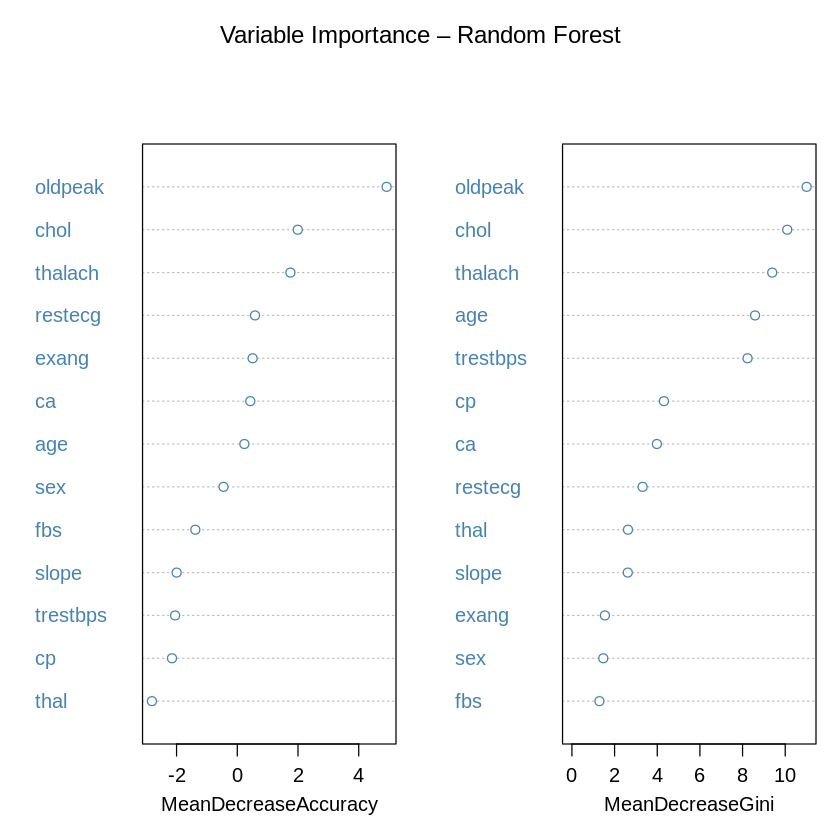

In [11]:
cat("\n===== Feature Importance =====\n")
importance_df <- as.data.frame(importance(rf_model))
importance_df$Feature <- rownames(importance_df)
importance_df <- importance_df[order(-importance_df$MeanDecreaseGini), ]
print(importance_df)

varImpPlot(rf_model,
           main = "Variable Importance – Random Forest",
           col  = "steelblue")

# 12. OOB Error vs ntree

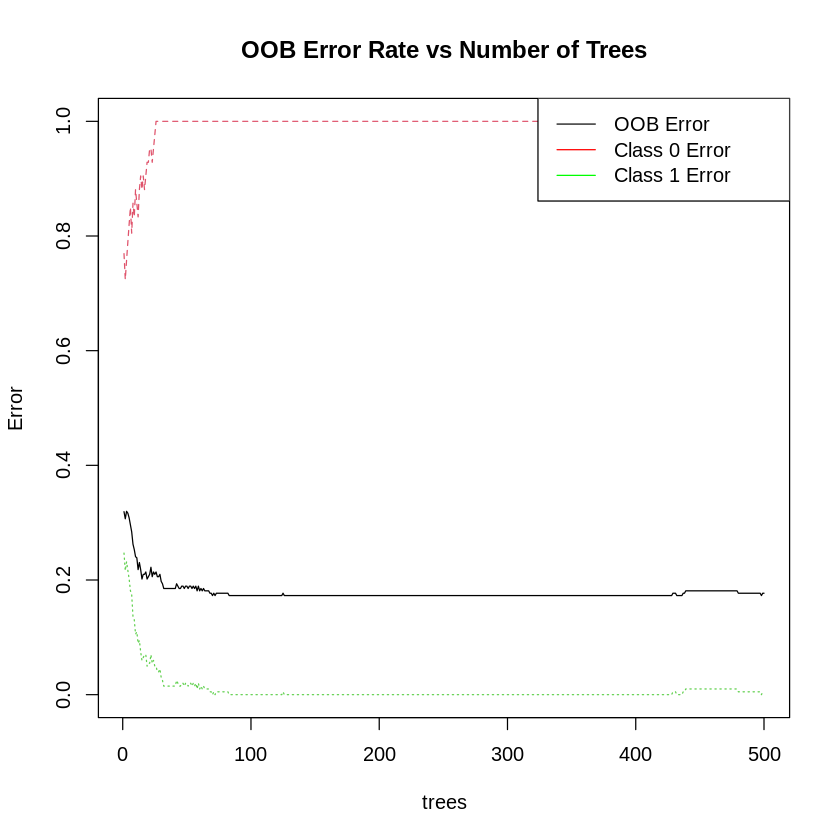

In [12]:
plot(rf_model,
     main = "OOB Error Rate vs Number of Trees")
legend("topright",
       legend = c("OOB Error", "Class 0 Error", "Class 1 Error"),
       col    = c("black", "red", "green"),
       lty    = 1)

# 13. Tune mtry


===== Tuning mtry =====
mtry = 3  OOB error = 17.28% 
Searching left ...
mtry = 2 	OOB error = 17.7% 
-0.02380952 0.01 
Searching right ...
mtry = 4 	OOB error = 18.93% 
-0.0952381 0.01 
Best mtry: 3 


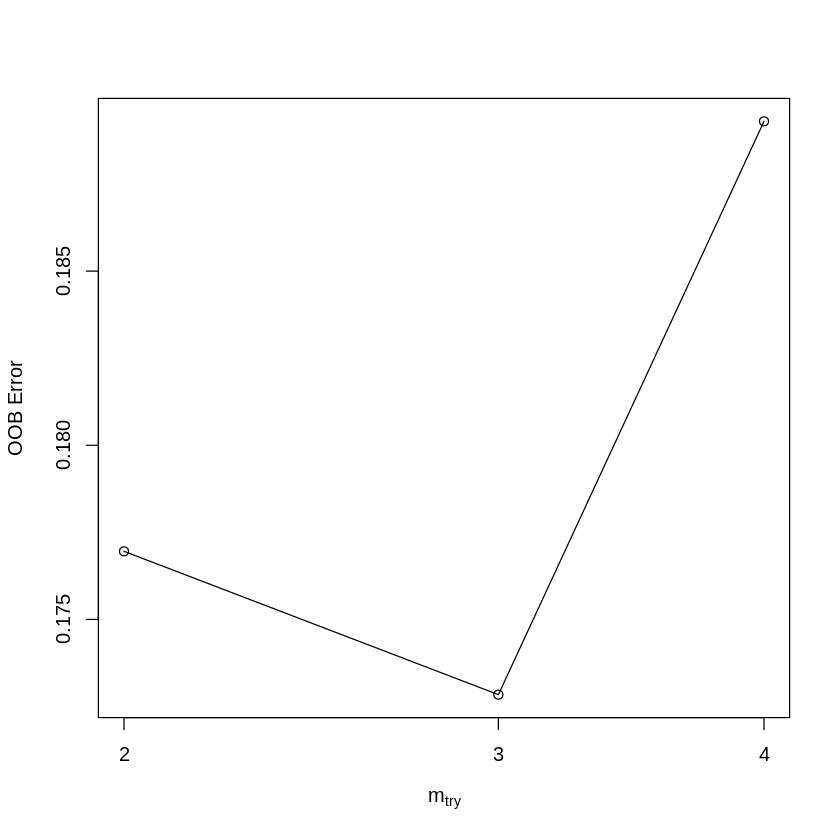

In [13]:
cat("\n===== Tuning mtry =====\n")
tuned <- tuneRF(train_data[, -ncol(train_data)],
                train_data$target,
                ntreeTry  = 200,
                stepFactor= 1.5,
                improve   = 0.01,
                trace     = TRUE,
                plot      = TRUE)
cat("Best mtry:", tuned[which.min(tuned[, 2]), 1], "\n")

# 14. Cross-Validation

In [16]:
cat("\n===== 5-Fold Cross-Validation =====\n")

# Relabel target factor levels to be valid R variable names for caret
heart_data_cv <- heart_data
levels(heart_data_cv$target) <- c("NoDisease", "Disease")

ctrl    <- trainControl(method = "cv", number = 5, classProbs = TRUE)
cv_model <- train(target ~ .,
                  data      = heart_data_cv, # Use the relabeled data
                  method    = "rf",
                  trControl = ctrl,
                  tuneLength = 3)
print(cv_model)


===== 5-Fold Cross-Validation =====
Random Forest 

303 samples
 13 predictor
  2 classes: 'NoDisease', 'Disease' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 243, 242, 242, 242, 243 
Resampling results across tuning parameters:

  mtry  Accuracy   Kappa      
   2    0.8284153   0.00000000
  11    0.8184699  -0.01796189
  20    0.8019672  -0.04586512

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was mtry = 2.
